In [125]:
from cifkit import CifEnsemble

# ensemble = CifEnsemble("tests/data/coordination", add_nested_files=True)
# print(ensemble.unique_CN_values_by_method_methods_stat)
CN_result = {10: 3, 12: 11, 13: 6, 14: 10, 16: 6, 17: 4, 7: 2, 11: 5, 15: 6, 6: 2, 8: 3, 18: 1, 9: 3}

# Specify the range of CN indices we are interested in
cn_indices = range(10, 16)  # From CN_10 to CN_15

# Retrieve counts for the specified range and compute the total
cn_counts = {cn: CN_result.get(cn, 0) for cn in cn_indices}
total_CN10_to_15_file_count = sum(cn_counts.values())

# Print the individual counts
print("Counts:",*[cn_counts[cn] for cn in cn_indices])
print("Total Count:", total_CN10_to_15_file_count)
cn_fractions = {cn: count / total_CN10_to_15_file_count for cn, count in cn_counts.items()}
print("Fractions:",*[f"{cn}: {cn_fractions[cn]:.2f}" for cn in cn_indices])



Counts: 3 5 11 6 10 6
Total Count: 41
Fractions: 10: 0.07 11: 0.12 12: 0.27 13: 0.15 14: 0.24 15: 0.15


(-2.0, 2.0, -2.0, 2.0)

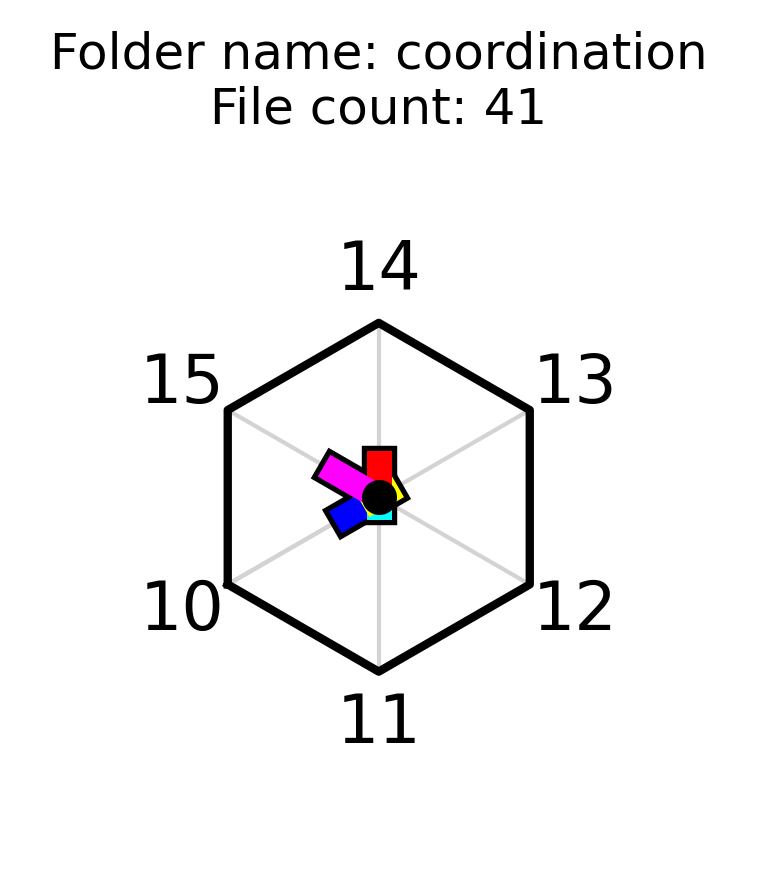

In [140]:
import random
import matplotlib.pyplot as plt
from core.system import hexagon 

center_pt = (0, 0)
# Generate five random numbers
random_numbers = [random.random() for _ in range(5)]

# Calculate their total sum
total_sum = sum(random_numbers)

# Normalize these numbers so that their sum is 1
bond_fractions = [num / total_sum for num in random_numbers]

# Add a sixth element to make the total sum exactly 1
bond_fractions.append(1 - sum(bond_fractions))

# Shuffle to randomize the position of the elements
random.shuffle(bond_fractions)

# Formula/structure label
bond_pairs = ["10", "11", "12", "13", "14", "15"]
fig, ax = plt.subplots(figsize=(3, 3.5), dpi=300)

# Individual hexagon (modified)
radius = 1
radius_padding = 0.2
label_offset = 0.3
bond_label_font_size = 16
outer_line_width = 2
color_line_width = 6
inner_line_width = 1
core_dot_radius = 55
label_radius = radius + label_offset

# Get the points for label positioning using the increased radius
x_label_pts, y_label_pts = hexagon.get_hexagon_points(center_pt, label_radius)

# Find minimum and maximum for both x and y from the hexagon points
x_min, x_max = min(x_label_pts), max(x_label_pts)
y_min, y_max = min(y_label_pts), max(y_label_pts)

ax.set_xlim(x_min - radius_padding, x_max + radius_padding)
ax.set_ylim(y_min - radius_padding, y_max + radius_padding)

for i, (x, y, label) in enumerate(zip(x_label_pts, y_label_pts, bond_pairs)):
    plt.text(
        x,
        y,
        label,
        fontsize=bond_label_font_size,  # Adjust fontsize as needed
        ha="center",  # Horizontal alignment
        va="center",  # Vertical alignment
    )
            
hexagon.draw_single_hexagon_and_lines_per_center_point(
    center_pt,
    bond_fractions,
    radius=radius,
    hex_inner_color="#D3D3D3",
    hex_outer_color="black",
    hex_inner_line_width=inner_line_width,
    hex_outer_line_width=outer_line_width,
    color_line_width=color_line_width,
    is_for_individual_hexagon=True,
)
folder_name = "coordination"
plt.title(f"Folder name: {folder_name}\nFile count: {total_CN10_to_15_file_count}")
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.scatter(0, 0, color="black", s=core_dot_radius, zorder=5)
plt.gca().set_aspect('equal', adjustable='box')
plt.axis("off")


